# Energy Consumption Prediction Model

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import xgboost as xgb
import optuna
import re

color_palette = sns.color_palette()
plt.style.use('fivethirtyeight')

## Feature Engineering

In [3]:
consumption_df = pd.read_csv('consumption_data.csv')
consumption_df['Datetime'] = pd.to_datetime(consumption_df['Datetime'])
consumption_df.set_index('Datetime', inplace=True)

<Axes: title={'center': 'Load Consumption Data'}, xlabel='Datetime', ylabel='Load Consumption (W)'>

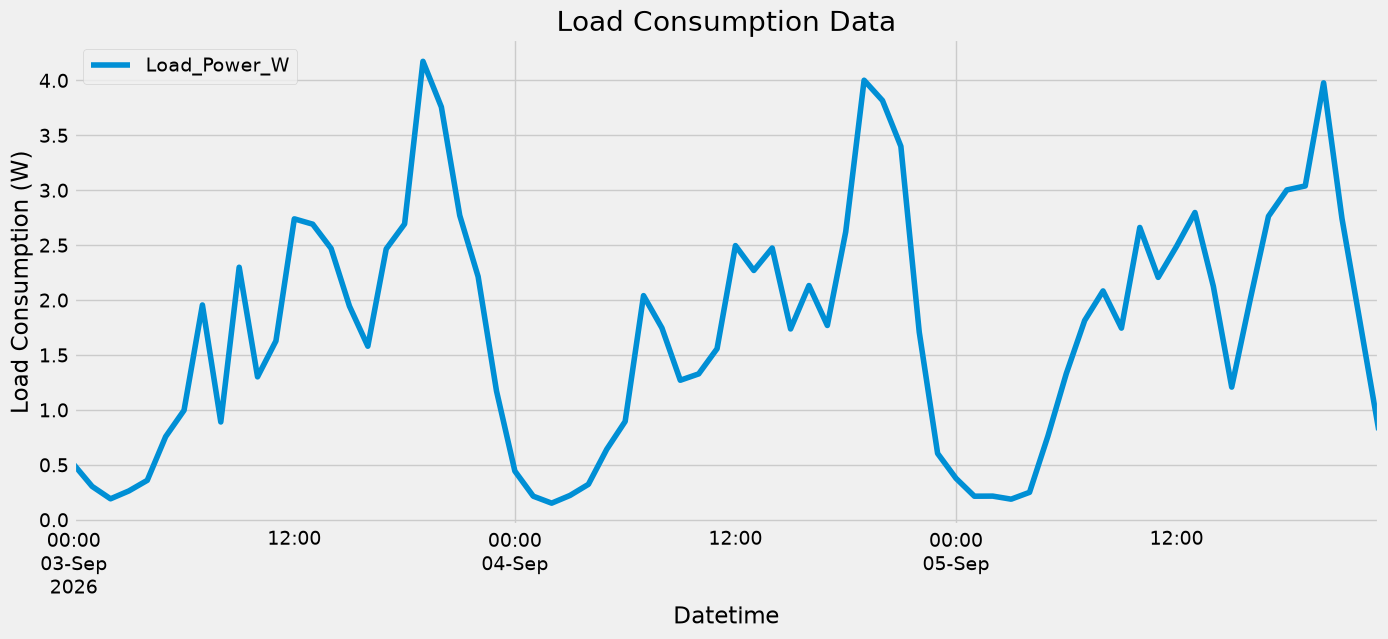

In [4]:
consumption_df.head()
consumption_df.plot(
    style='-',
    figsize=(15, 6),
    color=color_palette[0],
    title='Load Consumption Data',
    ylabel='Load Consumption (W)',
    xlabel='Datetime'
)

### Split datetime

In [5]:
consumption_df['year'] = consumption_df.index.year
consumption_df['month'] = consumption_df.index.month
consumption_df['dayofweek'] = consumption_df.index.dayofweek
consumption_df['hour'] = consumption_df.index.hour
consumption_df['dayofyear'] = consumption_df.index.dayofyear
consumption_df['is_weekend'] = (consumption_df.index.dayofweek >= 5).astype(int)

| Column | Description | Role |
|---|---|---|
| `Datetime` | Date and time of each measurement | Index |
| `Load_Power_W` | Measured load power in watts | Target |
| `year` | Calendar year | Feature |
| `month` | Month number from 1 to 12 | Feature |
| `dayofweek` | Day of week from Monday (0) to Sunday (6) | Feature |
| `hour` | Hour of the day from 0 to 23 | Feature |
| `dayofyear` | Day number from 1 to 365/366 | Feature |
| `is_weekend` | 1 for Saturday/Sunday, otherwise 0 | Feature |

### Data Visualisation

In [6]:
consumption_df.head()

,Load_Power_W,year,month,dayofweek,hour,dayofyear,is_weekend
Datetime,,,,,,,
2026-09-03 00:00:00,0.503345,2026,9,3,0,246,0
2026-09-03 01:00:00,0.303686,2026,9,3,1,246,0
2026-09-03 02:00:00,0.190737,2026,9,3,2,246,0
2026-09-03 03:00:00,0.262450,2026,9,3,3,246,0
2026-09-03 04:00:00,0.358949,2026,9,3,4,246,0


Text(0, 0.5, 'Load Power (W)')

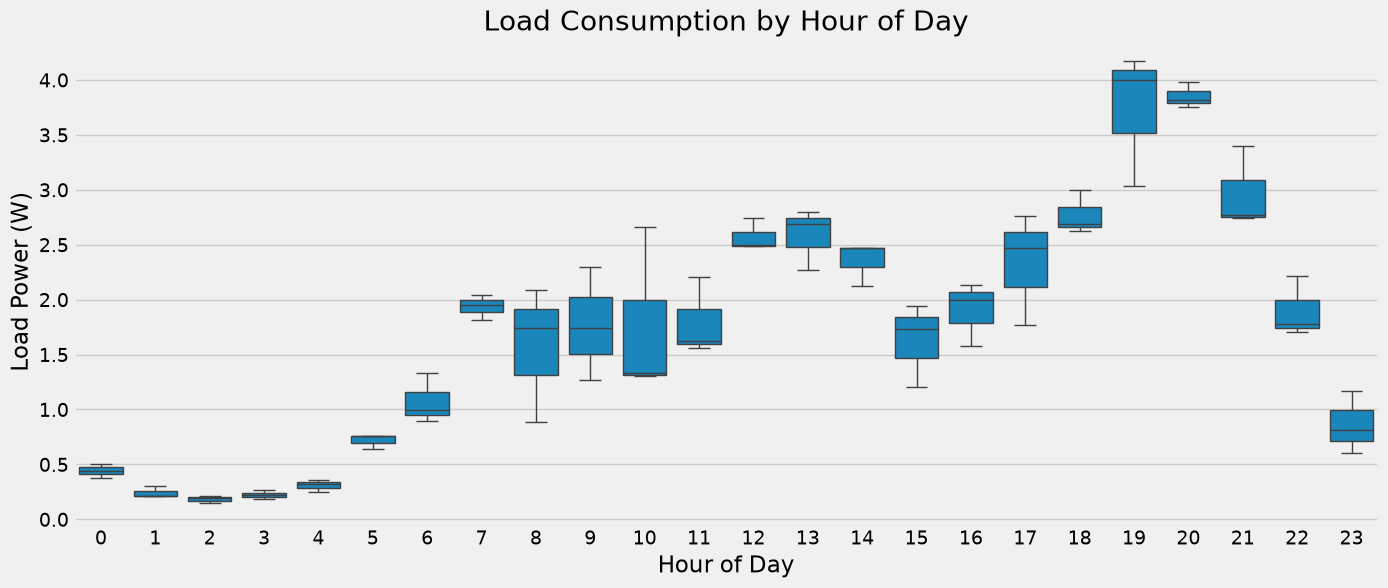

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(x='hour', y='Load_Power_W', data=consumption_df)
ax.set_title('Load Consumption by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Load Power (W)')

Text(0, 0.5, 'Load Power (W)')

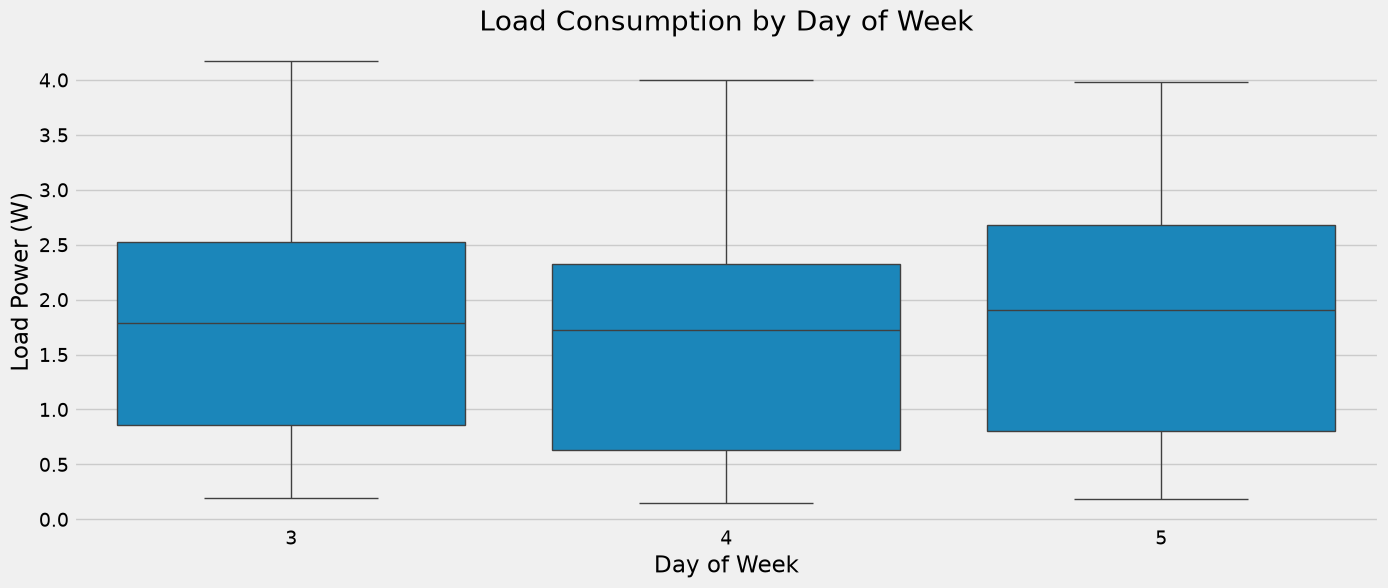

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(x='dayofweek', y='Load_Power_W', data=consumption_df)
ax.set_title('Load Consumption by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Load Power (W)')

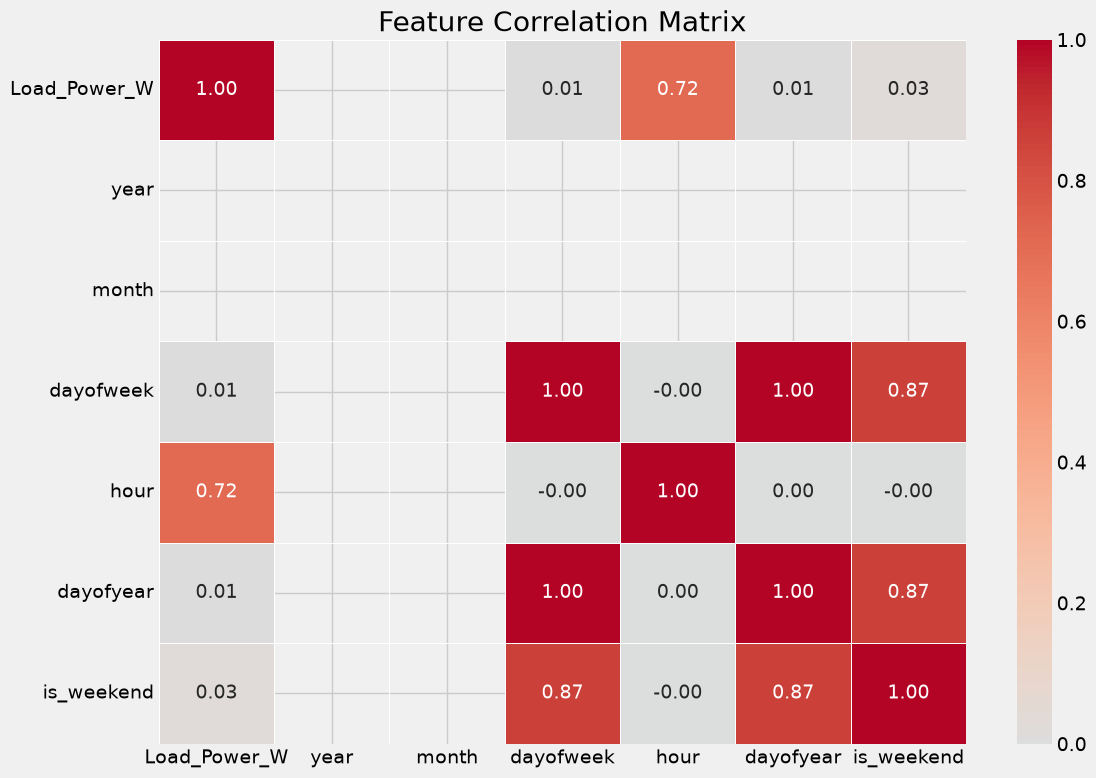

In [9]:
correlation_matrix = consumption_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()

## Splitting/Scaling

In [10]:
y = consumption_df['Load_Power_W'].copy()
X = consumption_df.drop('Load_Power_W', axis=1).copy()

## Train, Test and Validation

In [11]:
y = consumption_df['Load_Power_W'].copy()
X = consumption_df.drop('Load_Power_W', axis=1).copy()

X_train, X_remaining, y_train, y_remaining = train_test_split(
    X, y, test_size=0.3, shuffle=False, random_state=67
)

X_val, X_test, y_val, y_test = train_test_split(
    X_remaining, y_remaining, test_size=0.5, shuffle=False, random_state=67
)

In [12]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=67
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    train_size=0.8,
    random_state=69
)

In [14]:
# Convert to DMatrix form for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

## Model Training

In [15]:
def get_model_rmse(params):
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,
        evals=[(dval, 'eval')],
        early_stopping_rounds=10,
        verbose_eval=0
    )

    results = model.eval(dval)

    rmse = re.search(r'[\d.]+$', results)
    rmse = float(rmse.group())
    
    return rmse

In [16]:
def objective(trial):
    learning_rate = trial.suggest_loguniform('learning_rate', 0.00001, 1.0)
    max_depth = trial.suggest_int('max_depth', 4, 8)
    l1_reg = trial.suggest_loguniform('l1_reg', 0.00001, 10.0)
    l2_reg = trial.suggest_loguniform('l2_reg', 0.00001, 10.0)

    params = {
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'alpha': l1_reg,
        'lambda': l2_reg
    }

    return get_model_rmse(params)

In [17]:
study = optuna.create_study()
study.optimize(objective, n_trials=10, show_progress_bar=True)
best = study.best_params

[I 2026-09-03 18:58:10,375] A new study created in memory with name: no-name-88bcfb7e-9359-48e3-8ac3-4b276cb34ead
  0%|          | 0/10 [00:00<?, ?it/s]C:\Users\taro\AppData\Local\Temp\ipykernel_15544\3194397181.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 0.00001, 1.0)
C:\Users\taro\AppData\Local\Temp\ipykernel_15544\3194397181.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  l1_reg = trial.suggest_loguniform('l1_reg', 0.00001, 10.0)
C:\Users\taro\AppData\Local\Temp\ipykernel_15544\3194397181.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. 

[I 2026-09-03 18:58:10,455] Trial 0 finished with value: 0.4196769201310732 and parameters: {'learning_rate': 0.04519331350918005, 'max_depth': 4, 'l1_reg': 0.04190854412001737, 'l2_reg': 0.03200989101090808}. Best is trial 0 with value: 0.4196769201310732.
[I 2026-09-03 18:58:10,581] Trial 1 finished with value: 1.0587385920465369 and parameters: {'learning_rate': 0.00021803518080409662, 'max_depth': 7, 'l1_reg': 0.06290004536960618, 'l2_reg': 3.336835486994942e-05}. Best is trial 0 with value: 0.4196769201310732.
[I 2026-09-03 18:58:10,605] Trial 2 finished with value: 0.46052746078925005 and parameters: {'learning_rate': 0.8174165311701577, 'max_depth': 4, 'l1_reg': 0.9868291255105948, 'l2_reg': 0.013160456244242695}. Best is trial 0 with value: 0.4196769201310732.
[I 2026-09-03 18:58:10,630] Trial 3 finished with value: 0.6176906734653085 and parameters: {'learning_rate': 0.2706770789292719, 'max_depth': 6, 'l1_reg': 0.0029643843251429837, 'l2_reg': 0.0012733730837066796}. Best is 

Best trial: 0. Best value: 0.419677:  50%|█████     | 5/10 [00:00<00:00, 15.97it/s]

[I 2026-09-03 18:58:10,714] Trial 4 finished with value: 1.0763223002063584 and parameters: {'learning_rate': 4.6386860054468276e-05, 'max_depth': 6, 'l1_reg': 0.04209688429986198, 'l2_reg': 2.4110932330391158e-05}. Best is trial 0 with value: 0.4196769201310732.
[I 2026-09-03 18:58:10,804] Trial 5 finished with value: 1.0799158077818807 and parameters: {'learning_rate': 2.8178010842654188e-05, 'max_depth': 5, 'l1_reg': 2.1104570895372493e-05, 'l2_reg': 6.376731480260981}. Best is trial 0 with value: 0.4196769201310732.


Best trial: 0. Best value: 0.419677:  70%|███████   | 7/10 [00:00<00:00, 12.73it/s]

[I 2026-09-03 18:58:10,920] Trial 6 finished with value: 0.5776303029570674 and parameters: {'learning_rate': 0.009050552139836576, 'max_depth': 6, 'l1_reg': 0.09190639258088498, 'l2_reg': 0.013820026275779945}. Best is trial 0 with value: 0.4196769201310732.
[I 2026-09-03 18:58:11,031] Trial 7 finished with value: 1.0760444580395354 and parameters: {'learning_rate': 9.349875953436972e-05, 'max_depth': 6, 'l1_reg': 0.08049736998464009, 'l2_reg': 3.751262676157798}. Best is trial 0 with value: 0.4196769201310732.


Best trial: 0. Best value: 0.419677: 100%|██████████| 10/10 [00:00<00:00, 10.97it/s]

[I 2026-09-03 18:58:11,124] Trial 8 finished with value: 0.8864316209703906 and parameters: {'learning_rate': 0.009619898656749061, 'max_depth': 7, 'l1_reg': 6.774617013467882, 'l2_reg': 2.3570979794662273e-05}. Best is trial 0 with value: 0.4196769201310732.
[I 2026-09-03 18:58:11,285] Trial 9 finished with value: 1.076246820633708 and parameters: {'learning_rate': 4.6485621344849005e-05, 'max_depth': 8, 'l1_reg': 0.002165930389072731, 'l2_reg': 0.015063728677174974}. Best is trial 0 with value: 0.4196769201310732.


In [18]:
model = xgb.train(
    best,
    dtrain,
    num_boost_round=15,
    evals=[(dval, 'eval')],
    early_stopping_rounds=10
)

[0]	eval-rmse:1.04246
[1]	eval-rmse:1.00820
[2]	eval-rmse:0.97298


c:\Users\taro\Documents\School\University\Year 3\Sem B\ENGEE319\engee319\pred_env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [18:58:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "l1_reg", "l2_reg" } are not used.

  self.starting_round = model.num_boosted_rounds()


[3]	eval-rmse:0.93948
[4]	eval-rmse:0.90765
[5]	eval-rmse:0.87758
[6]	eval-rmse:0.85089
[7]	eval-rmse:0.82325
[8]	eval-rmse:0.79607
[9]	eval-rmse:0.77166
[10]	eval-rmse:0.74924
[11]	eval-rmse:0.72667
[12]	eval-rmse:0.70318
[13]	eval-rmse:0.68244
[14]	eval-rmse:0.66641


## Results

In [19]:
y_true = np.array(y_test, dtype=float)
y_pred = np.array(model.predict(dtest), dtype=float)

In [20]:
r2 = r2_score(y_true, y_pred)
print(f"R^2 Score: {r2:.2f}")

R^2 Score: 0.48


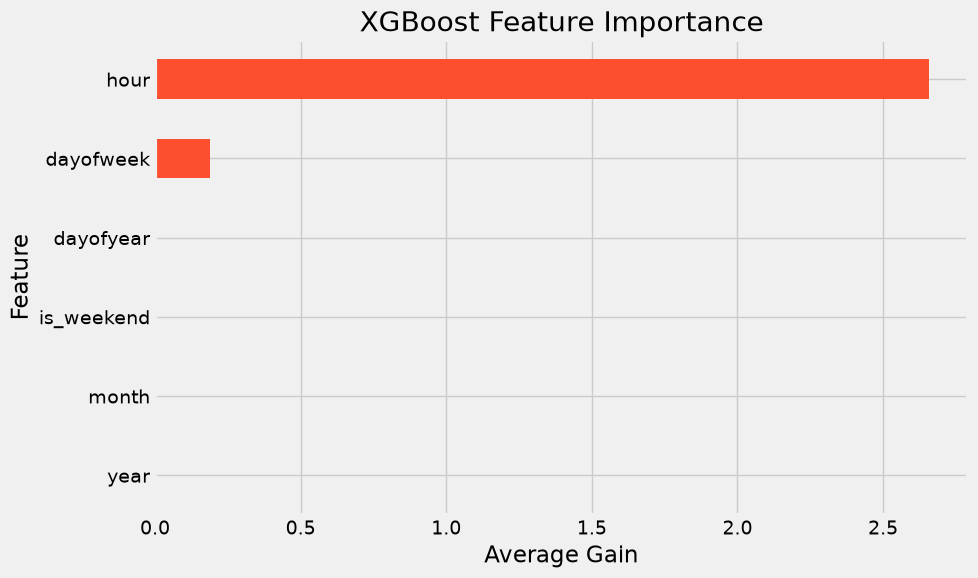

In [21]:
feature_names = consumption_df.drop('Load_Power_W', axis=1).columns
importance_scores = model.get_score(importance_type='gain')
feature_importance = pd.Series(
    {
        feature_names[int(feature[1:])]: score
        for feature, score in importance_scores.items()
    }
).reindex(feature_names, fill_value=0).sort_values()

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color=color_palette[1])
plt.title('XGBoost Feature Importance')
plt.xlabel('Average Gain')
plt.ylabel('Feature')
plt.tight_layout()